In [53]:
import get_ps_21cmEMU
import numpy as np
from getdist import MCSamples, plots
import torch
_ = torch.manual_seed(0)
import matplotlib.pyplot as plt
plt.style.use('sty.mplstyle')

In [25]:
# calling the emulator and getting the 1D power spectrum training data set

redshift_value = 8.01
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

ps_1_d = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)


def get_traning_data(theta, num_simulations):
    "first varying only three parameters: F_STAR10, F_ESC10, ALPHA_STAR"
    f_star_10 = theta[:, 0]
    f_esc_10 = theta[:, 1]
    alpha_star = theta[:, 2]
    # print(f_star_10, f_esc_10, alpha_star)

    ps_data = np.zeros((num_simulations, 32))

    for i in range(num_simulations):
        astro_params = {"F_STAR10": f_star_10[i], 
          'ALPHA_STAR': alpha_star[i],
          't_STAR': t_star,
          'F_ESC10': f_esc_10[i],
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }
        ps_data[i, :] = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
        
    return ps_data

In [26]:
# defining the parameter space for training data generation
from sbi.utils import BoxUniform
lower_bounds = np.array([-2.0, -3.0, 0.0])  # lower bounds for F_STAR10, F_ESC10, ALPHA_STAR
upper_bounds = np.array([-0.5, 0.0, 1.0])  # upper bounds for F_STAR10, F_ESC10, ALPHA_STAR
prior = BoxUniform(low=torch.tensor(lower_bounds), high=torch.tensor(upper_bounds))


In [27]:
# choosing the sbi method for inference: NPE
from sbi.inference import NPE
inference = NPE(prior=prior)

In [32]:
num_simulations = 1000
theta = prior.sample((num_simulations,))
x = get_traning_data(theta, num_simulations)
x_torch = torch.tensor(x, dtype=torch.float32)

In [30]:
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/ps_training_data_f_star10_f_esc10_alpha_star.npy', x)
# np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/theta_training_data_f_star10_f_esc10_alpha_star.npy', theta)

In [34]:
# performing inference using the training data set
inference = inference.append_simulations(theta, x_torch)
density_estimator = inference.train()

 Neural network successfully converged after 415 epochs.

In [36]:
posterior = inference.build_posterior()
print(posterior)


Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [39]:
ps_obs = get_ps_21cmEMU.simu_1d_ps(astro_params, redshift_value = redshift_value)
ps_obs_torch = torch.tensor(ps_obs, dtype=torch.float32)

In [40]:
posterior_samples = posterior.sample((1000,), x=ps_obs_torch)

  0%|          | 0/1000 [00:00<?, ?it/s]

Removed no burn in


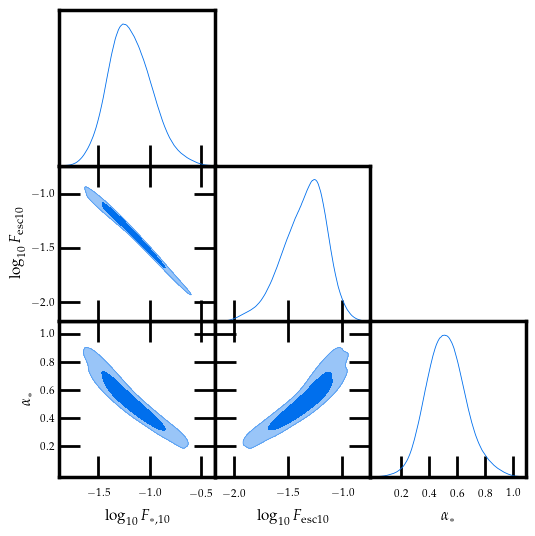

In [57]:
g = plots.get_subplot_plotter(width_inch=15, rc_sizes=True)
g.settings.axes_labelsize = 30
g.settings.legend_fontsize = 25
labels = [r'\log_{10} F_{*,10}', r'\log_{10} F_{\rm esc10}', r'\alpha_{*}']
names=['F_STAR10', 'F_ESC10', 'ALPHA_STAR']

samples = MCSamples(
    samples=posterior_samples.numpy(), 
    names=names,
    labels=labels
)

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)